# Energy Investment Analysis: Advanced vs Developing Economies (2015–2025)

## 1. Introduction & Real-World Context
This analysis examines how energy investment is allocated across different energy categories in advanced and developing economies. By comparing investment patterns over time, the analysis highlights structural differences in how economies at different stages of development approach the global energy transition.

### 1.1 Real-World Problem

**The core problem is how different economies allocate energy investment while balancing decarbonisation with development needs.** 

The global energy transition presents a central policy and investment challenge: how to expand energy supply to support economic development while simultaneously reducing carbon emissions. This challenge manifests differently across advanced and developing economies due to variations in infrastructure maturity, capital availability, energy demand growth, and policy constraints.

Advanced economies are generally focused on decarbonisation and system optimisation, whereas developing economies must balance clean energy investment with urgent needs for energy access, grid expansion, and economic growth. Understanding how energy investment is allocated across these economy types is critical for evaluating the pace, equity, and feasibility of the global energy transition.

### 1.2 Dataset Relevance

**The datasets allow me to compare both absolute investment and relative prioritisation between advanced and developing economies.**

The datasets used in this analysis provide aggregated annual energy investment data for advanced economies and emerging market and developing economies from 2015 to 2025. Investment is disaggregated by major categories, including total energy investment, clean energy, fossil fuels, power generation, and end-use efficiency.

These datasets are directly relevant to the real-world problem because they allow comparison of:
- absolute investment levels across economy types,
- the allocation of investment between clean and fossil energy,
- and how investment priorities evolve over time.

By structuring and joining the datasets, this analysis enables a clear, data-driven comparison of energy investment strategies between advanced and developing economies, offering insight into how different regions are navigating the trade-offs inherent in the global energy transition.


## 2. Data Loading
### 2.1 Import Required Libraries

In [11]:
# =========================
# LIBRARIES (Dependencies)
# =========================
# Purpose:
# - pandas: core library for tabular data manipulation (DataFrame/Series), similar to Excel but programmatic.
# - matplotlib.pyplot: foundational plotting library for visualisation (line/bar/scatter, etc.).
#
# Why this matters for the assignment:
# - The brief requires data loading, preparation, joins, simple analysis, and at least one plot.
# - pandas supports loading/cleaning/joining/aggregating.
# - matplotlib supports visualisation of the insights you generate from the joined data.
#
# Justfications for choices:
# - Why I used pandas → It provides DataFrame structures and vectorised operations for efficient analytics.
# - Why I used matplotlib → It is a standard Python plotting library that integrates cleanly with pandas outputs.
# - Why i imported with aliases → 'pd' and 'plt' are widely used conventions, improving readability.
#
# Technical detail:
# - These imports must run before any cell that calls pd.read_excel(...), df.merge(...), plt.figure(), plt.bar(), etc.
# - If you restart the kernel (common in vivas), you must re-run this cell to restore the imported namespaces.

import pandas as pd              # pd is the conventional alias for pandas, used throughout the notebook
import matplotlib.pyplot as plt  # plt is the conventional alias for pyplot, used to build charts


### 2.2 Define a defensive Excel loader (header detection)

This loader handles report-style Excel formatting (metadata rows, 'Unnamed' columns, blank separators) by detecting the true header row and returning a clean table.

#### 2.2.1 Load the two datasets consistently

Both datasets are loaded using the same function to ensure identical cleaning logic and comparable schemas.

In [12]:
# ===========================================================
# ROBUST EXCEL LOADER (REPORT-STYLE TABLE ➜ CLEAN DATAFRAME) - HELPER FUNCTION
# ===========================================================
# Purpose of this cell:
# - Define a reusable function that can load an Excel sheet even when it is formatted
#   like a report (title rows, merged cells, blank separators, "Unnamed" columns).
# - Automatically detect the true header row by searching for a known year (2015),
#   then reload the sheet using that row as the header.
#
# Why this matters (analytical decision):
# - These IEA-style tables often look like tidy data but are not stored as tidy tables.
# - Hardcoding skiprows is sometimes brittle: if the report format changes, skiprows may fail.
# - This function is a "defensive" approach that uses content-based detection of the header.
#
# Explanation of what I did: 
# - I wrote a helper function to robustly load Excel data where the header row is not fixed.
#    I detect the header row by locating the first row containing a known year (2015),
#    then re-read the file with that row as the header. This improves reliability.
#
# Technical note (important):
# - This cell defines a FUNCTION; it does not load data by itself until you call load_energy_table(...).
# - I USED A FUNCTION BECAUSE it reduces duplication and makes the pipeline repeatable for both datasets.

def load_energy_table(path, sheet_name=0):
    # -------------------------
    # Function inputs:
    # - path: string filepath to the Excel file
    # - sheet_name: which sheet to read (default 0 = first sheet)
    #
    # Function output:
    # - df: a cleaned pandas DataFrame with:
    #     • a stable "category" column
    #     • year columns (e.g., 2015–2025) as numeric header labels (stored as strings in pandas)
    #     • removal of obvious Excel artefacts ("Unnamed" columns, blank separator rows)
    # -------------------------

    # Load raw (no header) so we can search for the row that contains year labels like 2015
    # - header=None tells pandas: "treat every row as data; do not assume a header row"
    # - This gives a raw table where row indices are 0..n and columns are 0..m (integers).
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None)

    # Find the first row that contains the value 2015 (the year row in your screenshots)
    # - raw.apply(..., axis=1) applies a function to each ROW.
    # - For each row r:
    #     • r.astype(str) converts all cells in that row to strings
    #       (important because Excel may store years as floats/ints or text)
    #     • .str.contains(r"\b2015\b") searches for the exact token 2015
    #       (\b word boundaries prevent accidental matches like 20150)
    #     • .any() returns True if any cell in that row contains '2015'
    # - raw.index[...] returns the indices of rows that match.
    # - [0] selects the first matching row index, assuming 2015 appears in exactly one "header" row.
    #
    # Justification for choices:
    # - "Why search for 2015?" → It's a stable anchor year present in the table header (2015–2025),
    #   allowing automatic header detection without hardcoding skiprows.
    header_row = raw.index[
        raw.apply(
            lambda r: r.astype(str).str.contains(r"\b2015\b", regex=True).any(),
            axis=1
        )
    ][0]

    # Now reload using that row as the header
    # - header=header_row tells pandas: "use that row as column names"
    # - This converts the table into a more conventional DataFrame structure.
    df = pd.read_excel(path, sheet_name=sheet_name, header=header_row)

    # Clean column labels
    # - .astype(str) ensures all column names are strings (years may be numeric otherwise) (it's a method that returns a new DataFrame where the data types has been changed to the specified type.)
    # - .str.strip() removes hidden spaces that would break exact matches later (function, then method)
    df.columns = df.columns.astype(str).str.strip()

    # Drop columns like 'Unnamed: x'
    # - Excel often creates empty columns that pandas names "Unnamed: 0", "Unnamed: 1", etc.
    # - These columns are not analytical variables; they are formatting artefacts.
    # - df.loc[:, mask] selects columns using a boolean mask. (attribute that lets you select data from a DataFrame using labels.)
    # - ~ inverts the mask so we KEEP columns that are NOT Unnamed.
    df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", case=False, na=False)]

    # Rename first column to category (it’s the left-most label column)
    # - The first column holds labels like "Total Billion USD (2024, MER)", "Fuels", "Oil", etc.
    # - Renaming to "category" standardises downstream logic (melt, filtering, join keys).
    df = df.rename(columns={df.columns[0]: "category"})

    # Drop rows where category is missing (these are usually blank separators) (is a function)
    # - Blank separators occur in report-style spreadsheets between sections.
    # - They contain no category label, so they cannot represent meaningful observations.
    df = df.dropna(subset=["category"])

    # Drop rows that are section headers (keep rows with at least one numeric year value)
    # - Some rows are headings like "Fuels" or "Power" that may have no numeric values.
    # - We detect year columns by keeping only columns whose names are digits (e.g., "2015", "2016").
    # - year_cols is a list of year column names; this will be used to check for real data rows.
    year_cols = [c for c in df.columns if str(c).isdigit()] # .isdigit() is a built-in string method in Python that checks whether all the characters in a string are digits)

    # - dropna(how="all", subset=year_cols) removes rows where ALL year values are NaN,
    #   i.e., headings with no investment data.
    # - This preserves only categories that have at least one numeric investment value.
    df = df.dropna(how="all", subset=year_cols)

    # Return the cleaned DataFrame to the caller
    # - At this point, df is suitable for reshaping (melt) and quantitative analysis.
    return df


In [13]:
# =====================================
# APPLY ROBUST LOADER TO BOTH DATASETS
# =====================================
# Purpose of this cell:
# - Use the previously defined helper function to load and clean
#   both Excel files in a consistent, reproducible way.
#
# Why this matters (analytical decision):
# - Both datasets share the same report-style structure but represent
#   different economy groups.
# - Applying the same function ensures:
#     • identical cleaning logic
#     • comparable schemas
#     • fairness and validity in later comparisons
#
# Explanation of what I did: 
# - I used the same loading function for both datasets to guarantee
#    structural consistency before reshaping and joining.
#
# Technical note:
# - At this stage, advanced_df and developing_df are still in WIDE format:
#     • one row per investment category
#     • one column per year (2015–2025)
# - This is intentional; reshaping happens in the next step.

advanced_df = load_energy_table("Advanced Economies 2025 Energy Investment.xlsx")
# Loads and cleans the Advanced Economies energy investment table,
# automatically detecting the header row, removing Excel artefacts,
# and standardising the schema.

developing_df = load_energy_table("Developing Economies 2025 Energy Investment.xlsx")
# Loads and cleans the Developing Economies energy investment table
# using the exact same logic, ensuring the two datasets are directly comparable.



## 3. Data Preparation (Reshape + Validate)

This section converts the cleaned wide tables into tidy long format and performs post-reshape validation to ensure the data is analysis-ready.

### 3.2 Remove non-observations (missing investment values)

After reshaping, some rows may still represent structural artefacts. Rows with missing numeric investment values are removed so only valid observations remain.

In [14]:
# ==============================================================
# RESHAPE TO TIDY (LONG) FORMAT + TYPE ENFORCEMENT + VALIDATION
# ==============================================================
# Purpose of this cell:
# - Convert each dataset from WIDE format (years as columns) to LONG/TIDY format
#   (one row per category-year observation).
# - Enforce correct data types for the "year" column.
# - Add an economy-group label to support later comparison.
# - Validate that the transformation produced sensible outputs (years, shape).
#
# Why this matters (analytical decision):
# - Long format is the standard structure for:
#     • grouping/aggregation (groupby)
#     • joining datasets on keys (e.g., category + year)
#     • time-series comparisons and visualisations
# - It supports a clean relational design: each row becomes a single observation.
#
# Explanation of what I did: 
# - The original tables were wide, which is awkward for analysis and joining.
#    I reshaped them into tidy format so that category and year act as keys and
#    investment becomes the measurable value.

advanced_long = advanced_df.melt( #Used .melt() function to transform dataframe from wide to long format
    id_vars="category",              # "category" remains as an identifier (not reshaped)
    var_name="year",                 # the former column names (e.g., 2015, 2016...) become values in a new "year" column
    value_name="investment_billion_usd"  # the numeric cell values become the measurement column
)
# Result: advanced_long has columns [category, year, investment_billion_usd]
# and each row represents investment for one category in one year (advanced economies).

developing_long = developing_df.melt( #Used .melt() function to transform dataframe from wide to long format
    id_vars="category",              # same identifier column to keep schema aligned
    var_name="year",                 # year values stored as a variable rather than headers
    value_name="investment_billion_usd"  # investment values in billion USD
)
# Result: developing_long has the same tidy schema as advanced_long,
# enabling fair comparisons and safe joins later.

advanced_long["year"] = advanced_long["year"].astype(int) # .astype() method that returns a new DataFrame where the data types has been changed to the specified type.
# Converts the year column to integer.
# Why this matters:
# - ensures correct numeric ordering (2019 < 2020)
# - enables min/max checks, sorting, and time-based filtering (e.g., year == 2025)
# Assumption:
# - column names representing years are valid numeric strings (e.g., "2015").
# If this fails, it often means Excel artefacts (e.g., "Unnamed: 1") survived upstream.

developing_long["year"] = developing_long["year"].astype(int) # .astype() method returns a new DataFrame where the data types has been changed to the specified type.
# Applies the same type enforcement to the developing dataset so both datasets
# use identical data types (important for joins and comparisons).

advanced_long["economy_type"] = "Advanced"
# Adds a constant label so we can distinguish which economy group each row came from
# after concatenating or comparing datasets.

developing_long["economy_type"] = "Developing"
# Same economy-group label for the developing dataset.

# -------------------------
# QUICK VALIDATION CHECKS 
# -------------------------
# These prints verify:
# - the year range matches expectations (2015–2025)
# - the DataFrame is not empty
# - the shape (rows, columns) looks reasonable after reshaping
# If the year min/max shows NaN or weird values, it signals a parsing/cleaning issue.
print("Advanced:", advanced_long["year"].min(), advanced_long["year"].max(), advanced_long.shape) # min and max function + shape property (NumPy)
print("Developing:", developing_long["year"].min(), developing_long["year"].max(), developing_long.shape) # min and max function + shape property (NumPy)

advanced_long.head()
# Displays the first five rows of the final tidy advanced dataset.
# Schema sanity check (what I expect):
# - category: string labels such as "Fossil fuels" or "of which: Clean energy"
# - year: integer between 2015 and 2025
# - investment_billion_usd: numeric (float) investment value (Billion USD)
# - economy_type: "Advanced"
#
# Viva prompt:
# - "Why tidy format?" → It standardises the dataset for joins, groupby operations, and plotting.
# - "Why validate here?" → It confirms the transformation worked before analysis continues.


Advanced: 2015 2025 (407, 4)
Developing: 2015 2025 (407, 4)


,category,year,investment_billion_usd,economy_type
0,"Total Billion USD (2024, MER)",2015,1176.9,Advanced
1,of which: Clean energy,2015,571.8,Advanced
2,Fuels,2015,553.7,Advanced
3,Fossil fuels,2015,550.8,Advanced
4,Oil,2015,338.4,Advanced


In [15]:
# =========================
# 3.2 REMOVE NON-OBSERVATIONS (POST-RESHAPE)
# =========================
# Why this exists:
# - After reshaping (melt), some rows can still be structural artefacts (blank Excel rows, section dividers).
# - Rows with missing investment values are not valid observations for aggregation or plotting.
# - We drop NaNs in the *measure* column only, so we don't accidentally discard valid categories/years.

advanced_long = advanced_long.dropna(subset=["investment_billion_usd"])   # keep only rows with a numeric investment value (Advanced)
developing_long = developing_long.dropna(subset=["investment_billion_usd"]) # keep only rows with a numeric investment value (Developing)


## 4. Dataset Integration (Join Operation)

This section joins the two economy-group datasets on shared keys to enable direct comparison of equivalent categories in the same year.

### 4.1 Join Advanced and Developing Economy Data

In [16]:
# ==========================================================
# DATASET INTEGRATION: JOIN ADVANCED & DEVELOPING ECONOMIES
# ==========================================================
# Purpose of this cell:
# - Combine the advanced and developing economy datasets into a single DataFrame
#   so that equivalent investment categories can be directly compared year by year.
#
# Why this matters for the assignment:
# - The brief explicitly requires performing at least one join.
# - This join is not arbitrary: it enables a meaningful analytical comparison
#   across economy types for the same category and year.
#
# Real-world analytical rationale:
# - By aligning data on BOTH category and year, we ensure that comparisons
#   reflect the same type of investment (e.g., clean energy) in the same time period.
# - This avoids misleading comparisons across different categories or years.
#
# Explanation of what I did: 
# - I joined the datasets on category and year using an inner join to ensure
#    that I only compared equivalent investment categories in the same year
#    across advanced and developing economies.

joined_df = advanced_long.merge( # .merge() method updates the content of two DataFrame by merging them together
    developing_long,                 # Right-hand DataFrame (developing economies)
    on=["category", "year"],          # Join keys: category AND year must match in both datasets
    how="inner",                      # Inner join keeps only rows present in BOTH datasets
    suffixes=("_advanced", "_developing")  
    # Suffixes distinguish columns with the same name (e.g., investment values)
    # after the merge, preventing naming collisions.
)

# Technical details:
# - pandas.merge performs a relational-style join similar to SQL JOIN.
# - An inner join is appropriate here because:
#     • it ensures comparability
#     • it avoids introducing NaNs from unmatched categories or years
# - The resulting DataFrame contains:
#     • category
#     • year
#     • investment_billion_usd_advanced
#     • economy_type_advanced
#     • investment_billion_usd_developing
#     • economy_type_developing
#
# Analytical assumption:
# - Categories and years present in both datasets are directly comparable.
# - Categories not shared by both economy types are excluded by design.

joined_df.head() # method to return a number of rows (5 if not specified)
# Displays the first five rows of the joined dataset.
# This serves as a sanity check to confirm:
# - the join succeeded
# - investment values from both economy types appear side by side
# - category and year alignment is correct
#
# Justification of choices:
# - "Why inner join?" → To ensure only comparable category-year combinations are analysed.
# - "What question does this enable?" → Direct comparison of energy investment allocation
#   between advanced and developing economies over time.


,category,year,investment_billion_usd_advanced,economy_type_advanced,investment_billion_usd_developing,economy_type_developing
0,"Total Billion USD (2024, MER)",2015,1176.9,Advanced,1439.7,Developing
1,of which: Clean energy,2015,571.8,Advanced,580.4,Developing
2,Fuels,2015,553.7,Advanced,732.0,Developing
3,Fossil fuels,2015,550.8,Advanced,728.6,Developing
4,Oil,2015,338.4,Advanced,438.7,Developing


### 4.2 Verify Join Integrity

In [17]:
# ====================================
# POST-JOIN VALIDATION & SANITY CHECKS
# ====================================
# Purpose of this cell:
# - Verify that the join operation produced a sensible and analytically valid dataset.
# - Confirm that the merged data contains:
#     • a reasonable number of rows and columns
#     • the expected range of years
#     • meaningful investment categories
#
# Why this matters for the assignment:
# - The brief assesses your ability to explain analytical decisions.
# - Validation after a join is a critical analytical step that demonstrates
#   you did not blindly assume the merge worked as intended.
#
# Explanation of what I did: 
# - After joining the datasets, I ran validation checks to confirm that the
#    shape, time coverage, and categories matched my expectations before
#    proceeding to analysis.
#
# Technical details:
# - joined_df.shape returns a tuple (rows, columns), giving an overview of dataset size.
# - .unique() returns the distinct values in a column.
# - sorted(...) is applied to the year values to make the temporal range explicit.
# - Slicing [:10] is used for categories to keep output readable in the notebook.

print("Joined shape:", joined_df.shape) # .shape is attribute from NumPy
# Displays the dimensions of the joined dataset.
# This helps confirm that:
# - the dataset is non-empty
# - the join did not unexpectedly drop too many rows
# - the number of columns aligns with expectations after merging two tables.

print("Unique years:", sorted(joined_df["year"].unique())) # .unique is a NumPy function to return unique values
# Lists all distinct years present in the joined dataset, sorted in ascending order.
# This confirms that:
# - the full expected time range (e.g., 2015–2025) is preserved
# - no invalid or missing year values remain after cleaning and merging.

print("Example categories:", joined_df["category"].unique()[:10])
# Displays a sample of investment categories present in the joined dataset.
# This serves as a quick check that:
# - category labels are meaningful (e.g., clean energy, fossil fuels)
# - no section headers or non-data labels survived the cleaning process.
#
# Justification of choices:
# - "Why validate after the join?" → To ensure the merge logic produced a coherent
#   dataset before performing aggregation or visualisation.
# - "What would concern you here?" → Unexpected year gaps, empty datasets,
#   or category labels that indicate remaining non-data rows.


Joined shape: (473, 6)
Unique years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Example categories: ['Total Billion USD (2024, MER)' 'of which: Clean energy' 'Fuels'
 'Fossil fuels' 'Oil' 'Gas' 'Coal' 'Clean Fuels' 'Direct Air Capture'
 'Power']


## 5. Targeted Analysis (2025 Snapshot)

This section focuses on 2025 to provide a clear, contemporary comparison of investment priorities.

### 5.1 Filter Data for Policy-Relevant Year

In [18]:
# ============================================================
# FOCUSED SUBSET FOR TARGETED ANALYSIS (YEAR + KEY CATEGORIES)
# ============================================================
# Purpose of this cell:
# - Create a focused subset of the joined dataset that isolates:
#     • a single, policy-relevant year (2025)
#     • two analytically important energy categories (Clean energy and Fossil fuels)
#
# Why this matters analytically:
# - Narrowing the dataset reduces noise and sharpens the analytical question.
# - 2025 represents the most recent year in the dataset and is therefore
#   the most relevant for contemporary energy transition discussions.
# - Clean energy vs fossil fuels captures the central tension of the
#   global energy transition: decarbonisation versus energy security.
#
# Explanation of what I did: 
# - I filtered the joined dataset to focus on 2025 and on clean energy
#    versus fossil fuels so that the analysis directly reflects current
#    investment priorities and transition trade-offs.
#
# Technical details:
# - Boolean indexing is used to apply multiple conditions simultaneously.
# - The '&' operator combines conditions and must be wrapped in parentheses.
# - .isin([...]) checks membership against a list of category values.
# - .copy() creates an explicit copy to avoid SettingWithCopyWarning
#   if this subset is modified later.

analysis_2025 = joined_df[ # isin() function is designed to quickly and efficiently check whether certain values exist in a DataFrame
    (joined_df["year"] == 2025) &                                  # Condition 1: keep only observations from the year 2025
    (joined_df["category"].isin(["of which: Clean energy",         # Condition 2: keep only clean energy
                                 "Fossil fuels"]))                #               and fossil fuel investment categories
].copy() # The copy() method returns a copy of the specified list

analysis_2025
# Displays the filtered dataset.
# Expected structure:
# - One row per category (clean energy, fossil fuels)
# - Investment values for both advanced and developing economies side by side
#
# Justification of my choices:
# - "Why filter before plotting?" → To ensure the visualisation answers
#   a clear, specific analytical question rather than showing unnecessary data.
# - "Why use .copy()?" → To safely work with a subset without risking
#   unintended side effects on the original joined dataset.


,category,year,investment_billion_usd_advanced,economy_type_advanced,investment_billion_usd_developing,economy_type_developing
431,of which: Clean energy,2025,1065.8,Advanced,1009.2,Developing
433,Fossil fuels,2025,342.8,Advanced,637.2,Developing


### 5.2 Select Key Energy Categories

In [19]:
# ===========================================
# RESHAPE DATA FOR COMPARATIVE VISUALISATION
# ===========================================
# Purpose of this cell:
# - Prepare the filtered 2025 dataset for plotting by converting it into
#   a format that is suitable for side-by-side comparison.
#
# Why this matters analytically:
# - The current structure (wide format) stores investment values for
#   advanced and developing economies in separate columns.
# - For most plotting functions, especially comparative bar charts,
#   it is clearer to have:
#     • one column indicating the group (economy type)
#     • one column containing the numeric values
# - This step therefore restructures the data into a tidy, plot-friendly format.
#
# Explanation of what I did: 
# - I reshaped the data again so that economy type becomes a variable
#    rather than a column, which simplifies comparative visualisation.
#
# Technical details:
# - This is a second use of melt(), applied to a *subset* of the data.
# - id_vars identifies columns that remain fixed (category).
# - value_vars specifies which columns are being unpivoted into rows.
# - var_name becomes the column that identifies the economy type.
# - value_name becomes the numeric investment value column.

plot_df = analysis_2025.melt(
    id_vars=["category"],                                      # Category remains the identifier (clean energy vs fossil fuels)
    value_vars=[
        "investment_billion_usd_advanced",                     # Investment values for advanced economies
        "investment_billion_usd_developing"                    # Investment values for developing economies
    ],
    var_name="economy",                                        # New column indicating which economy the value came from
    value_name="investment_billion_usd"                        # New column holding the numeric investment values
)

# At this stage, the 'economy' column contains technical column names
# (e.g., 'investment_billion_usd_advanced'), which are not presentation-friendly.

plot_df["economy"] = plot_df["economy"].replace({
    "investment_billion_usd_advanced": "Advanced economies",    # .replace() method replaces technical label with human-readable category
    "investment_billion_usd_developing": "Developing economies"
})
# This mapping improves interpretability in both the table output and the plot legend.

plot_df
# Displays the final plotting DataFrame.
# Expected structure:
# - category: Clean energy or Fossil fuels
# - economy: Advanced economies / Developing economies
# - investment_billion_usd: numeric investment value for 2025
#
# Justification of my choices:
# - "Why reshape again?" → To make the data suitable for comparative plotting.
# - "Why rename values in 'economy'?" → To improve clarity and readability
#   when communicating results visually.


,category,economy,investment_billion_usd
0,of which: Clean energy,Advanced economies,1065.8
1,Fossil fuels,Advanced economies,342.8
2,of which: Clean energy,Developing economies,1009.2
3,Fossil fuels,Developing economies,637.2


## 6. Visualisation & Insight

This section visualises the analysis results to support a simple, interpretable insight.

### 6.1 Visualise Energy Investment Allocation

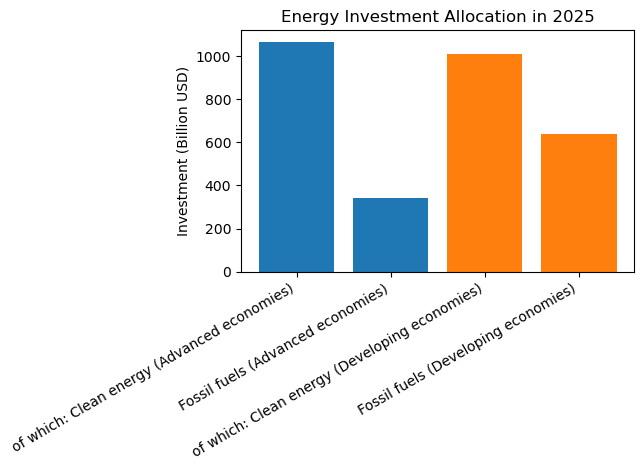

In [20]:
# =========================
# VISUALISATION: ENERGY INVESTMENT ALLOCATION (2025)
# =========================
# Purpose of this cell:
# - Create a clear bar chart that compares energy investment levels
#   between advanced and developing economies for key categories in 2025.
#
# Why this matters analytically:
# - Visualisation helps translate numeric results into an interpretable insight.
# - A bar chart is appropriate because:
#     • we are comparing discrete categories (Clean energy vs Fossil fuels)
#     • across a small number of groups (two economy types)
# - This directly supports the analytical question:
#   "How do energy investment priorities differ between advanced and developing economies?"
#
# Explanation of what I did: 
# - I used a bar chart to compare clean energy and fossil fuel investment
#    across economy types in 2025, as it makes relative differences immediately visible.

plt.figure()
# Creates a new figure object.
# This ensures the plot does not overlap with any previous visualisations.

for econ in plot_df["economy"].unique(): # .unique() function returns a NumPy array containing all the unique elements in a data series
    # Iterates over each unique economy type in the dataset
    # (e.g., 'Advanced economies' and 'Developing economies').

    subset = plot_df[plot_df["economy"] == econ]
    # Filters the plotting DataFrame to include only rows for the current economy type.
    # This creates a small subset used to plot bars for that group.

    plt.bar(
        subset["category"] + " (" + econ + ")",    # X-axis labels combine category and economy for clarity
        subset["investment_billion_usd"]            # Y-axis values are the investment amounts (Billion USD)
    )
    # Each iteration adds bars for one economy type.
    # Using separate labels ensures bars are distinguishable without relying on colour alone.

plt.ylabel("Investment (Billion USD)")
# Labels the y-axis to clearly communicate the unit of measurement.

plt.title("Energy Investment Allocation in 2025")
# Provides a concise, descriptive title indicating both the subject and the time frame.

plt.xticks(rotation=30, ha="right")
# Rotates x-axis labels slightly to prevent overlap and improve readability,
# especially when labels include both category and economy type.

plt.tight_layout()
# Automatically adjusts spacing so labels and titles fit within the figure area.

plt.show()
# Renders the plot.
#
# Interpretation guidance (for viva):
# - This chart shows how advanced and developing economies allocate investment
#   between clean energy and fossil fuels in 2025.
# - Differences in bar heights illustrate contrasting priorities and constraints
#   in the global energy transition.
#
# Justification of my choices:
# - "Why a bar chart?" → Because it clearly compares discrete categories across groups.
# - "What insight does it support?" → Differences in investment allocation between
#   advanced and developing economies at a single point in time.


### 6.2 Clean Energy Share of Total Energy Investment (2025)

While absolute investment levels are informative, relative allocation provides deeper insight into strategic priorities. This section examines the proportion of total energy investment allocated to clean energy in advanced and developing economies.

In [21]:
# =============================================================
# BASIC ANALYSIS: CLEAN ENERGY SHARE OF TOTAL INVESTMENT (2025)
# =============================================================
# Purpose of this cell:
# - Calculate the proportion of total energy investment allocated to clean energy
#   for advanced and developing economies in the year 2025.
#
# Why this matters analytically:
# - Absolute investment levels can be misleading when economies differ in size.
# - Calculating a percentage share allows comparison of *prioritisation* rather than scale.
# - This directly addresses the question:
#   "How much of total energy investment is directed toward clean energy?"
#
# Explanation of what I did: 
# - I calculated clean energy as a share of total investment to compare
#    strategic prioritisation between economy types, independent of scale.

# --- Filter data to the target year (2025) ---
share_2025 = joined_df[joined_df["year"] == 2025].copy()
# Keeps only observations from 2025, the most recent and policy-relevant year.
# .copy() method is used to safely create a new DataFrame for this analysis step.

# --- Identify the correct category labels in the dataset ---
TOTAL_LABEL = "Total Billion USD (2024, MER)"
# Label representing total energy investment across all categories.
# This value comes directly from the dataset and must match exactly.

CLEAN_LABEL = "of which: Clean energy"
# Label representing the subset of investment allocated to clean energy.

# --- Extract total investment values ---
total_investment = share_2025.loc[
    share_2025["category"] == TOTAL_LABEL,
    ["investment_billion_usd_advanced", "investment_billion_usd_developing"]
]
# Filters the dataset to the total-investment row and selects the numeric
# investment values for both economy types.

# --- Extract clean energy investment values ---
clean_investment = share_2025.loc[
    share_2025["category"] == CLEAN_LABEL,
    ["investment_billion_usd_advanced", "investment_billion_usd_developing"]
]
# Filters the dataset to the clean-energy row and selects the corresponding
# investment values for both economy types.

# --- Defensive validation checks ---
# Purpose:
# - Prevent silent errors if category labels change or are misspelled.
# - Ensure the analysis fails loudly rather than producing misleading results.
if total_investment.empty or clean_investment.empty:
    raise ValueError(
        f"Expected category labels not found. "
        f"Check category values for '{TOTAL_LABEL}' and '{CLEAN_LABEL}'. "
        f"Available examples: {share_2025['category'].unique()[:10]}"
    )
# If either DataFrame is empty, it means the expected rows were not found.
# Raising an error here is intentional and demonstrates analytical responsibility.

# --- Compute clean energy share (%) ---
clean_share = (clean_investment.values / total_investment.values) * 100
# Uses element-wise division to calculate the percentage of total investment
# allocated to clean energy for each economy type.
#
# Technical note:
# - .values returns NumPy arrays, enabling vectorised arithmetic.
# - Multiplying by 100 converts the ratio into a percentage.

# --- Present results in a clear summary table ---
clean_share_df = pd.DataFrame({
    "Economy": ["Advanced economies", "Developing economies"],
    "Clean energy share (%)": [
        float(clean_share[0][0]),   # Clean energy share for advanced economies
        float(clean_share[0][1])    # Clean energy share for developing economies
    ]
})
# Creates a small, human-readable summary table suitable for display
# and direct interpretation in the notebook or viva.

clean_share_df
# Displays the clean energy share results.
#
# Interpretation guidance (for viva):
# - Higher values indicate a greater prioritisation of clean energy
#   within total energy investment.
# - Comparing these percentages highlights structural differences
#   in how advanced and developing economies approach the energy transition.
#
# Justification of my choices:
# - "Why percentages instead of totals?" → To compare prioritisation independent of scale.
# - "What assumption is made?" → That the 'Total' category accurately represents
#   overall energy investment for each economy type.


,Economy,Clean energy share (%)
0,Advanced economies,74.703862
1,Developing economies,57.062083


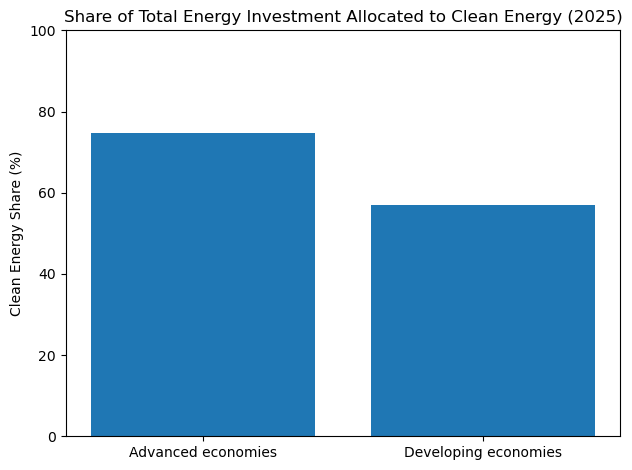

In [22]:
# ============================================================
# VISUALISATION: CLEAN ENERGY SHARE OF TOTAL INVESTMENT (2025)
# ============================================================
# Purpose of this cell:
# - Visualise the proportion of total energy investment allocated to clean energy
#   for advanced and developing economies in 2025.
#
# Why this matters analytically:
# - Percentages are easier to compare visually than raw numbers when focusing on priorities.
# - A bar chart is well-suited for comparing a small number of discrete groups.
# - This visual directly supports the insight derived from the clean energy share calculation.
#
# Explanation of what I did: 
# - I used a bar chart to clearly compare the share of total energy investment
#    allocated to clean energy between advanced and developing economies.

plt.figure()
# Creates a new figure to ensure this plot is rendered independently
# and does not overlap with previous visualisations.

plt.bar(
    clean_share_df["Economy"],                 # X-axis: economy types (Advanced vs Developing)
    clean_share_df["Clean energy share (%)"]   # Y-axis: clean energy share as a percentage
)
# Plots one bar per economy type.
# The height of each bar represents the proportion of total investment
# directed toward clean energy.

plt.ylabel("Clean Energy Share (%)")
# Labels the y-axis to clearly communicate that values are percentages,
# not absolute investment amounts.

plt.title("Share of Total Energy Investment Allocated to Clean Energy (2025)")
# Provides a concise and informative title indicating:
# - what is being measured (clean energy share),
# - and the time frame (2025).

plt.ylim(0, 100)
# Sets the y-axis limits explicitly from 0 to 100.
# This is analytically appropriate because percentages are bounded
# and it prevents visual exaggeration of differences.

plt.tight_layout()
# Automatically adjusts spacing to ensure labels and titles fit
# neatly within the figure area.

plt.show()
# Renders the plot.
#
# Interpretation guidance (for viva):
# - The difference in bar heights highlights how much priority each
#   economy type gives to clean energy relative to total investment.
# - This supports discussion about structural differences in
#   energy transition strategies.
#
# Justification of my choices:
# - "Why a bar chart?" → Because it clearly compares proportions across groups.
# - "What insight does it support?" → That advanced economies allocate a
#   larger share of their energy investment to clean energy than developing economies.


# 7. AI Declaration

## Responsible Use of AI

## Responsible Use of AI

AI tools were used as a **supporting aid** during the development of this notebook, in line with responsible academic and professional coding practices.

### AI Prompts Used
AI was prompted with requests such as:
- Guidance on structuring Python data-analysis workflows using pandas.
- Assistance with reshaping Excel-style datasets into tidy (long) format.
- Debugging support when validation checks indicated unexpected results.
- Suggestions for appropriate visualisations to support simple analytical insights.

### What AI Helped With
AI assisted primarily with:
- Recalling correct pandas syntax (e.g., melt, merge, filtering logic).
- Identifying common Excel-related data issues (metadata rows, unnamed columns).
- Suggesting defensive programming practices, such as validation checks.
- Helping articulate analytical steps clearly through code comments.
- Articulating the real world context, problem, and relevance of the datasets

### What I Verified or Changed Myself
All AI-assisted suggestions were **reviewed, validated, and adapted** manually. In particular:
- I verified dataset structure using inspection methods (head(), info(), validation prints).
- I confirmed join keys, join type, and filtering logic based on the analytical question.
- I adjusted category labels to match the dataset exactly.
- I interpreted all results and ensured that visualisations accurately reflected the data.
- I ensured that comments reflect my own understanding and that I can explain every line of code in the viva.

### How AI Improved Code Quality
AI was used as a **learning and quality-assurance tool**, not as a replacement for understanding. It helped:
- Reduce syntactic errors and improve code clarity.
- Encourage defensive checks that prevent silent analytical mistakes.
- Improve readability and documentation so the analysis is transparent and reproducible.

Overall, AI enhanced efficiency and code robustness, while all analytical decisions, interpretations, and validations remained my own responsibility.
